In [1]:
#!/usr/bin/env python

import numpy as np
from ase.io import read
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt
import pandas as pd


for traj_file, out_file in [("npt_run3.traj", "rmsd_run3.dat")]:
    print(f"Processing trajectory: {traj_file}")

    # ===== user settings =====
    pdb_file = "openmm/step3_input.pdb"     # starting structure (topology + reference)
    # traj_file = "npt_run3.traj"         # ASE trajectory (.traj)
    sel_str = "protein and name CA"  # atom selection for RMSD (e.g. backbone, all, etc.)
    # out_file = "rmsd_run3.dat"            # output text file
    # =========================


    # 1) Load reference structure with MDAnalysis
    u = mda.Universe(pdb_file)
    sel = u.select_atoms(sel_str)

    # Save reference coordinates (from PDB)
    ref_coords = sel.positions.copy()

    # 2) Load all frames from ASE trajectory
    # ":" means read all frames
    images = read(traj_file, ":")

    rmsd_values = []

    for i, atoms in enumerate(images):
        # ASE positions are in Angstrom by default, same as MDAnalysis
        coords = atoms.get_positions()
        if coords.shape[0] != u.atoms.n_atoms:
            raise ValueError(
                f"Frame {i}: atom count mismatch "
                f"(traj: {coords.shape[0]}, pdb: {u.atoms.n_atoms})"
            )

        # Update MDAnalysis universe coordinates for this frame
        u.atoms.positions = coords

        # Select same atoms after updating coordinates
        mob_coords = sel.positions

        # 3) Compute RMSD (Å), with alignment to reference
        rmsd_val = rms.rmsd(mob_coords, ref_coords,
                            center=True, superposition=True)
        rmsd_values.append(rmsd_val)

    # 4) Save to file
    rmsd_values = np.array(rmsd_values)
    frames = np.arange(len(rmsd_values), dtype=int)

    data = np.column_stack((frames, rmsd_values))
    header = f"# frame  rmsd(Å)  selection='{sel_str}'  ref='{pdb_file}'"

    np.savetxt(out_file, data, header=header, fmt=["%8d", "%12.6f"])




/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing trajectory: npt_run3.traj


/tmp/ipykernel_2414251/1424674164.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv("rmsd_run1.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])
/tmp/ipykernel_2414251/1424674164.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv("rmsd_run2.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])
/tmp/ipykernel_2414251/1424674164.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df3 = pd.read_csv("rmsd_run3.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])


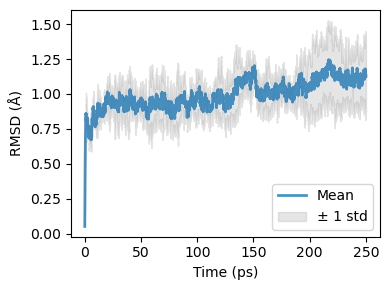

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read data
df1 = pd.read_csv("rmsd_run1.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])
df2 = pd.read_csv("rmsd_run2.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])
df3 = pd.read_csv("rmsd_run3.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"])

# Combine data
frames = df1["frame"].values
rmsd1 = df1["rmsd"].values
rmsd2 = df2["rmsd"].values
rmsd3 = df3["rmsd"].values

# Calculate mean and standard deviation
rmsd_mean = (rmsd1 + rmsd2 + rmsd3) / 3
rmsd_std = np.sqrt(((rmsd1 - rmsd_mean)**2 + (rmsd2 - rmsd_mean)**2 + (rmsd3 - rmsd_mean)**2) / 2)

# Create plot
plt.figure(figsize=(4, 3))
plt.plot(frames/100, rmsd_mean, 'C0', linewidth=2, label='Mean', alpha=0.8)
plt.fill_between(frames/100, rmsd_mean - rmsd_std, rmsd_mean + rmsd_std, 
                 color='gray', alpha=0.2, label='± 1 std')
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend()
plt.tight_layout()
plt.show()